In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
# dataset using 
deliveris=pd.read_csv('deliveries.csv') # dataset of all the ball of the ipl 
matches=pd.read_csv('matches.csv')      # dataset of the matches record in the ipl 
matches.columns

Index(['id', 'Season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='str')

# this project is to make a ml model which predict the win-rate of the teams in ipl match 

solution - to predict wheter a team will win or not we have to get the target they are chasing their current run rate , their required run rate , wickets in-hand , batsmen on field , teams that are playing 

In [3]:
df=deliveris.groupby(['match_id','inning']).sum()['total_runs'].reset_index()
df=df[df['inning']==1]
df=df.merge(matches,left_on='match_id',right_on='id')
df.columns

Index(['match_id', 'inning', 'total_runs', 'id', 'Season', 'city', 'date',
       'team1', 'team2', 'toss_winner', 'toss_decision', 'result',
       'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets',
       'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3'],
      dtype='str')

In [ ]:
#df.drop(columns=['umpire1','umpire2','umpire3'],inplace=True)
df_c=df.copy()

In [5]:
# renaming old teams name into current 
df_c['team1']=df['team1'].replace({'Delhi Daredevils':'Delhi Capitals', 'Deccan Chargers':'Sunrisers Hyderabad',})
df_c['team2']=df['team2'].replace({'Delhi Daredevils':'Delhi Capitals', 'Deccan Chargers':'Sunrisers Hyderabad',})

In [ ]:
# removing teams which now not exist 
team=['Sunrisers Hyderabad',           
'Mumbai Indians',                
'Kings XI Punjab',                
'Chennai Super Kings',          
'Royal Challengers Bangalore',   
'Kolkata Knight Riders',        
'Delhi Capitals',             
'Rajasthan Royals',]
#df_c=df_c[df_c['team1'].isin(team)]
#df_c=df_c[df_c['team2'].isin(team)]
#<--------------------------------------->

# we do not want the data which have rain or dl applied
#df_c=df_c[df_c['dl_applied']==0]

df_c=df_c[['match_id', 'total_runs','winner','city']]

In [7]:
# merging with deliveris 
df_final=deliveris.merge(df_c,on='match_id')
df_f=df_final.copy()


In [8]:
# runs left to chase
df_f['current_score']=df_f[df_f['inning']==2].groupby('match_id')['total_runs_x'].cumsum()
df_f['run_left']=df_f['total_runs_y']+1-df_f['current_score']


In [9]:
# balls left 
df_f['ball_left']=126-(df_f['over']*6+df_f['ball'])


In [ ]:
# wickets_left
#df_f['player_dismissed']=df_f['player_dismissed'].fillna('0')
#df_f['player_dismissed']=df_f['player_dismissed'].apply(lambda x: x if x=='0' else '1')
df_f['player_dismissed']=df_f['player_dismissed'].astype('int')
df_f['wickets_left']=10-df_f[df_f['inning']==2].groupby('match_id')['player_dismissed'].cumsum()


In [11]:
# current run rate 
df_f['crr']=df_f['current_score']*6/(120-df_f['ball_left'])

# required run rate

df_f['rrr']=(df_f['run_left']*6)/df_f['ball_left']

In [38]:
# adding result

def check(data):
    return 1 if data['winner']==data['batting_team'] else 0

df_f['result']=df_f.apply(check,axis=1)
# <--------------------------------------------------------------------->

# extracting useful columns
train=df_f[df_f['inning']==2][['batting_team','bowling_team','city','current_score', 'run_left', 
      'ball_left', 'wickets_left', 'crr', 'rrr','total_runs_y','result']]

In [39]:
# final training data 
train=train.sample(train.shape[0],random_state=1)
train.dtypes

batting_team         str
bowling_team         str
city                 str
current_score    float64
run_left         float64
ball_left          int64
wickets_left     float64
crr              float64
rrr              float64
total_runs_y       int64
result             int64
dtype: object

<------------------------------------->
 EDA on the data 

 1. data have 72,413 sample with 11 features 
 2. total_runs mean==median approx to  normal distribution
 3. have to fix the infinite values in rrr
 4. fixing city na values



In [57]:
#train.dropna(inplace=True)
train=train[train['ball_left']!=0]


(71342, 11)

<Axes: xlabel='total_runs_y', ylabel='Density'>

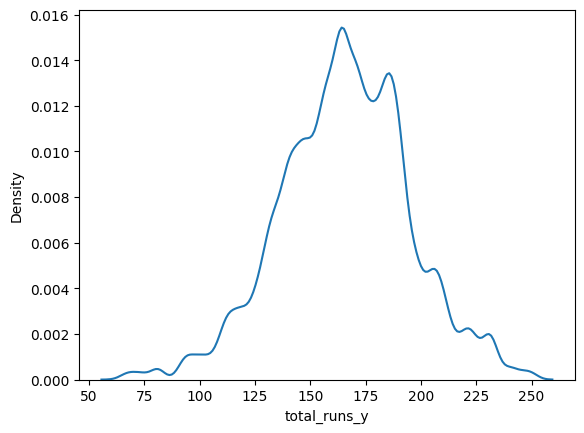

In [58]:
sns.kdeplot(data=train,x='total_runs_y')

In [79]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [63]:
X=train.iloc[:,:-2]
Y=train.iloc[:,-1]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.8,random_state=42)


(57073, 9)

In [91]:
trnf=ColumnTransformer(transformers= [('ohe',OneHotEncoder(),['batting_team','bowling_team','city'])],
                       remainder='passthrough')

model_lr=Pipeline(steps=[('step1',trnf),
('step2',LogisticRegression())])


In [92]:
model_lr.fit(X_train,Y_train)

c:\Users\adity\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('step1', ...), ('step2', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse 

In [94]:
y_pred=model_lr.predict(X_test)
acc=accuracy_score(Y_test,y_pred)
model_lr.predict_proba(X_test)


array([0.72430761, 0.27569239])

In [99]:
import pickle
pickle.dump(model_lr,open('model_lr.pkl','wb'))
